## Classification for Time Series
### Variable target: rating_category
#### K-NN with features extraction and Dynamic Time Warping

In [73]:
import numpy as np
import pandas as pd
from tslearn.neighbors import KNeighborsTimeSeriesClassifier
from tslearn.metrics import dtw
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score

In [74]:
ts_imdb = pd.read_csv('TS_NO_OUTLIERS.csv').drop(columns=['id', 'rating'])

ts_imdb.head()

,0,1,2,3,4,5,6,7,8,9,...,genre_Music,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Short,genre_Sport,genre_Thriller,genre_War,genre_Western
0,57057.0,65469.0,71642.0,73025.0,74060.0,49472.0,30258.0,28036.0,25824.0,32571.0,...,0,0,0,0,1,0,0,0,0,0
1,1923.0,2422.0,2853.0,2947.0,3054.0,2844.0,2617.0,1998.0,1277.0,1449.0,...,0,0,0,1,0,0,0,0,0,0
2,332925.0,302503.0,267264.0,261879.0,256608.0,196530.0,112728.0,117384.0,123024.0,119608.0,...,1,0,0,0,0,0,0,0,0,0
3,682857.0,407032.0,78058.0,81732.0,86772.0,83724.0,79940.0,39656.0,6974.0,7697.0,...,0,0,0,0,1,0,0,0,0,0
4,7813372.0,6274563.0,4781588.0,4655046.0,4535301.0,4650574.0,4758452.0,4069428.0,3471755.0,3108057.0,...,0,0,0,0,0,0,0,0,0,0


In [75]:
# Analisi preliminare del target
print("Distribuzione delle classi nel target 'rating_category':")
print(ts_imdb['rating_category'].value_counts())
print(f"\nNumero di classi uniche: {ts_imdb['rating_category'].nunique()}")

# split train e test
X_train, X_test, y_train, y_test = train_test_split(
    ts_imdb, ts_imdb['rating_category'], test_size=0.2, random_state=42
)

Distribuzione delle classi nel target 'rating_category':
rating_category
2    387
4    361
3    226
1    128
0     10
Name: count, dtype: int64

Numero di classi uniche: 5


In [76]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((889, 123), (223, 123), (889,), (223,))

In [77]:
y_train.value_counts(), y_test.value_counts()

(rating_category
 2    303
 4    298
 3    177
 1    103
 0      8
 Name: count, dtype: int64,
 rating_category
 2    84
 4    63
 3    49
 1    25
 0     2
 Name: count, dtype: int64)

In [78]:
columns_with_numbers = [col for col in X_train.columns if any(char.isdigit() for char in col)]

X_train = X_train[columns_with_numbers]
X_test = X_test[columns_with_numbers]

X_train.shape, X_test.shape


((889, 100), (223, 100))

In [79]:
X_train.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
866,41168.0,32440.0,20720.0,17099.0,12926.0,8204.0,4267.0,4588.0,4888.0,4525.0,...,20462.0,18334.0,13180.0,7453.0,8312.0,9049.0,7887.0,6761.0,8426.0,9746.0
994,143178.0,124106.0,105062.0,98003.0,90759.0,60091.0,36945.0,35405.0,33989.0,34388.0,...,23369.0,23866.0,21434.0,18720.0,11339.0,5580.0,5613.0,5645.0,6048.0,6510.0
1024,1195749.0,1097450.0,941145.0,804830.0,674809.0,485976.0,341835.0,363161.0,379454.0,323941.0,...,182721.0,122728.0,88299.0,65285.0,75978.0,83029.0,70214.0,59165.0,53194.0,47974.0
781,2479596.0,2263895.0,2090362.0,1731658.0,1418412.0,1042710.0,603983.0,731893.0,830296.0,724115.0,...,6345.0,5915.0,4110.0,2904.0,3409.0,3993.0,3397.0,2757.0,3005.0,3221.0
898,25754.0,26850.0,27803.0,22728.0,18100.0,12767.0,6035.0,5757.0,5498.0,5954.0,...,109289.0,83800.0,54688.0,29940.0,34157.0,38770.0,36538.0,33895.0,33369.0,32730.0


In [80]:
# Reimpostazione degli indici per X_train e X_test

index_values_train = list(range(0, X_train.shape[0]))
index_values_test = list(range(0, X_test.shape[0]))
X_train.index = index_values_train
X_test.index = index_values_test

X_train.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,41168.0,32440.0,20720.0,17099.0,12926.0,8204.0,4267.0,4588.0,4888.0,4525.0,...,20462.0,18334.0,13180.0,7453.0,8312.0,9049.0,7887.0,6761.0,8426.0,9746.0
1,143178.0,124106.0,105062.0,98003.0,90759.0,60091.0,36945.0,35405.0,33989.0,34388.0,...,23369.0,23866.0,21434.0,18720.0,11339.0,5580.0,5613.0,5645.0,6048.0,6510.0
2,1195749.0,1097450.0,941145.0,804830.0,674809.0,485976.0,341835.0,363161.0,379454.0,323941.0,...,182721.0,122728.0,88299.0,65285.0,75978.0,83029.0,70214.0,59165.0,53194.0,47974.0
3,2479596.0,2263895.0,2090362.0,1731658.0,1418412.0,1042710.0,603983.0,731893.0,830296.0,724115.0,...,6345.0,5915.0,4110.0,2904.0,3409.0,3993.0,3397.0,2757.0,3005.0,3221.0
4,25754.0,26850.0,27803.0,22728.0,18100.0,12767.0,6035.0,5757.0,5498.0,5954.0,...,109289.0,83800.0,54688.0,29940.0,34157.0,38770.0,36538.0,33895.0,33369.0,32730.0


In [81]:
# normalization

from tslearn.preprocessing import TimeSeriesScalerMeanVariance

# Scaling per time series (media 0, std 1 su ogni serie)
scaler = TimeSeriesScalerMeanVariance()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape, X_test_scaled.shape

c:\Users\curia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\curia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The TimeSeriesScalerMeanVariance or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
c:\Users\curia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed 

((889, 100, 1), (223, 100, 1))

In [82]:
# KNN with DTW
import tslearn
from tslearn.neighbors import KNeighborsTimeSeriesClassifier
from sklearn.model_selection import RandomizedSearchCV

knn_dtw = KNeighborsTimeSeriesClassifier(metric="dtw", n_jobs=-1)

param_distributions = {
    'n_neighbors': np.arange(1, 21),
    'weights': ['uniform', 'distance'],
    'metric_params': [
        {'sakoe_chiba_radius': r} for r in [3, 5, 7, 9, 11]
    ]
}

random_search = RandomizedSearchCV(
    estimator=knn_dtw,
    param_distributions=param_distributions,
    n_iter=50, 
    scoring='f1_macro',
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_scaled, y_train)

c:\Users\curia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The KNeighborsTimeSeriesClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Fitting 5 folds for each of 50 candidates, totalling 250 fits


c:\Users\curia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\curia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The KNeighborsTimeSeriesClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
c:\Users\curia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The KNeighborsTimeSeriesClassifier or classes from which it inherits use `_get_tags` 

RandomizedSearchCV(cv=5, estimator=KNeighborsTimeSeriesClassifier(n_jobs=-1),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'metric_params': [{'sakoe_chiba_radius': 3},
                                                          {'sakoe_chiba_radius': 5},
                                                          {'sakoe_chiba_radius': 7},
                                                          {'sakoe_chiba_radius': 9},
                                                          {'sakoe_chiba_radius': 11}],
                                        'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20]),
                                        'weights': ['uniform', 'distance']},
                   random_state=42, scoring='f1_macro', verbose=2)

In [83]:
print("Best parameters:", random_search.best_params_)

# Evaluation on the test set
best_knn = random_search.best_estimator_
y_pred = best_knn.predict(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, y_pred))

c:\Users\curia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Best parameters: {'weights': 'uniform', 'n_neighbors': np.int64(9), 'metric_params': {'sakoe_chiba_radius': 3}}
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.40      0.16      0.23        25
           2       0.46      0.63      0.54        84
           3       0.17      0.12      0.14        49
           4       0.48      0.48      0.48        63

    accuracy                           0.42       223
   macro avg       0.30      0.28      0.28       223
weighted avg       0.39      0.42      0.39       223



c:\Users\curia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The KNeighborsTimeSeriesClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
c:\Users\curia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\curia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklear

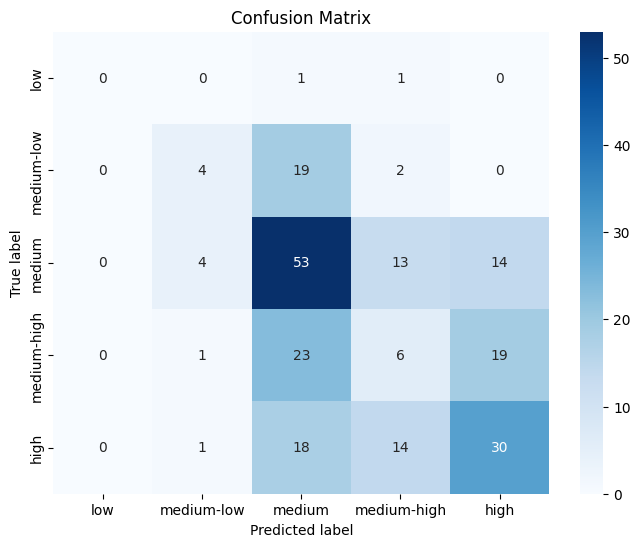

In [84]:
# Confusion matrix visualization
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# target names
class_names = ['low', 'medium-low', 'medium', 'medium-high', 'high']

# Calcola la confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()


c:\Users\curia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The KNeighborsTimeSeriesClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
c:\Users\curia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\curia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The KNeighborsTimeSeriesClassifier or classes from which it inherits use `_get_tags` 

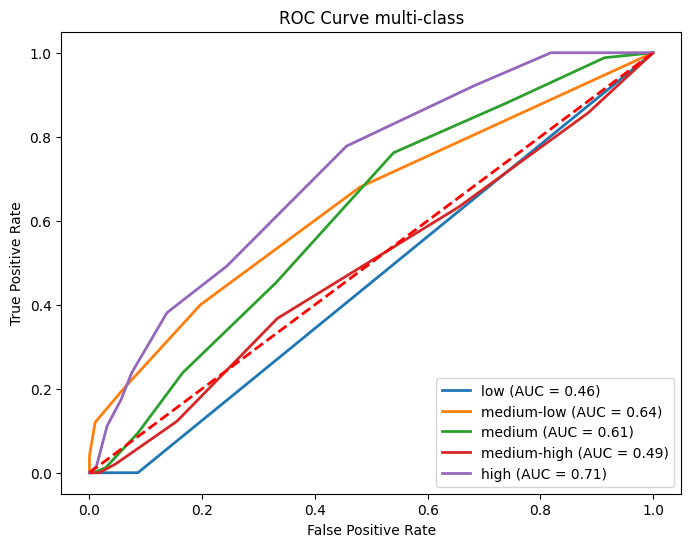

In [85]:
# Roc Curve and AUC
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Definisci le classi e i loro nomi
classes = [0, 1, 2, 3, 4]
class_names = ['low', 'medium-low', 'medium', 'medium-high', 'high']

# Binarizza le etichette di test per multi-classe (one-vs-rest)
y_test_bin = label_binarize(y_test, classes=classes)

# Probabilità predette dal modello KNN (probabilità per ogni classe)
y_score = best_knn.predict_proba(X_test_scaled)

plt.figure(figsize=(8, 6))

for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label='{} (AUC = {:.2f})'.format(class_names[i], roc_auc))

plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')  # Linea di non discriminazione
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve multi-class')
plt.legend(loc='lower right')
plt.show()


c:\Users\curia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


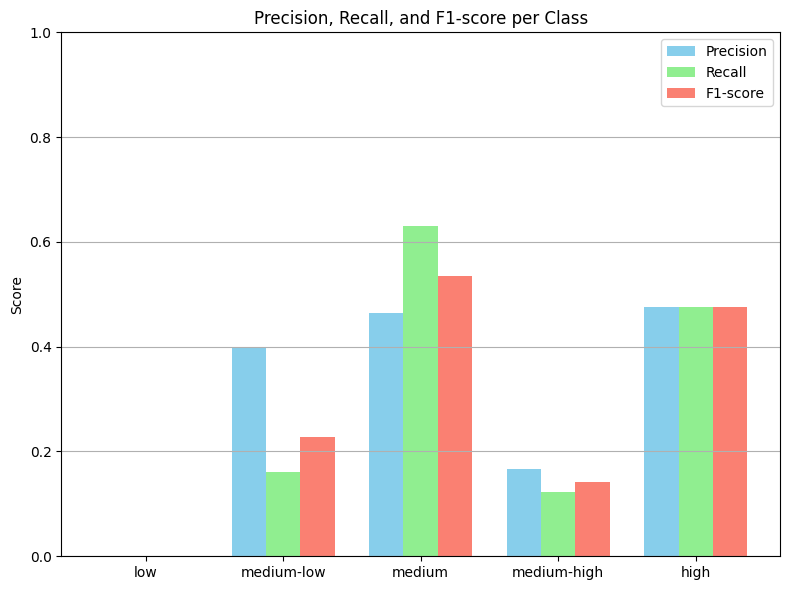

In [86]:
from sklearn.metrics import precision_score, recall_score, f1_score

# precision, recall, and F1-score
precision = precision_score(y_test, y_pred, average=None, labels=[0,1,2,3,4])
recall = recall_score(y_test, y_pred, average=None, labels=[0,1,2,3,4])
f1 = f1_score(y_test, y_pred, average=None, labels=[0,1,2,3,4])

# visualization
x = np.arange(len(class_names))  # posizione centrale per ogni classe
width = 0.25  # larghezza delle barre

# createplot
plt.figure(figsize=(8, 6))
plt.bar(x - width, precision, width=width, label='Precision', color='skyblue')
plt.bar(x, recall, width=width, label='Recall', color='lightgreen')
plt.bar(x + width, f1, width=width, label='F1-score', color='salmon')

plt.xticks(x, class_names)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-score per Class')
plt.legend()
plt.grid(axis='y')

plt.tight_layout()
plt.show()
